# Deepfake Detection — Tiền xử lý & Trích đặc trưng (phần A + B)

Notebook này lo **Dữ liệu (A)** và **Đặc trưng (B)**, xuất ra các file `.pkl` để **bàn giao cho người C** train model (phần C nằm ở file/notebook riêng).

**Luồng:** ảnh → resize 256×256 (xám) → **ảnh dư PCA** (bỏ 32 thành phần chính) → **FFT (64) + LBP (59) + Noise (64)** → feature vector **187 chiều** → chuẩn hóa → chia 80/10/10 → lưu `train/val/test.pkl` + `scaler.pkl`.

| Người | Nhiệm vụ | Trong file này |
|---|---|---|
| **A — Data** | Lấy `project_data`, giải nén, resize, chia 80/10/10 | ✅ có |
| **B — Features** | FFT + LBP + Noise → ghép feature vector + `feature_groups` cho ablation | ✅ có |
| **C — Model** | Train SVM/RF/GBM, đánh giá, ablation | ➡️ bàn giao (file `.pkl`) |

> Chạy tuần tự từ trên xuống. **Output bàn giao C:** `train.pkl`, `val.pkl`, `test.pkl`, `scaler.pkl` — mỗi file kèm `feature_groups` để C tự chạy ablation.


In [1]:
!pip install scikit-image tqdm -q


In [2]:
import os, zipfile

DATA_DIR = '/content/project_data'
ZIP_OUT  = '/content/project_data.zip'
FILE_ID  = '1hKCgB5upHkUhb-baWL_2zN74JQoYC7A4'

if not os.path.isdir(DATA_DIR):
    zip_path = None

    try:
        from google.colab import drive
        drive.mount('/content/drive')
        candidates = [
            '/content/drive/MyDrive/Deepfake_project/project_data.zip',
            '/content/drive/Shareddrives/Deepfake_project/project_data.zip',
        ]
        zip_path = next((p for p in candidates if os.path.exists(p)), None)
    except Exception as e:
        print('[INFO] Bỏ qua mount Drive:', e)

    if zip_path is None:
        import gdown
        print('[INFO] Không thấy ZIP trong Drive -> tải bằng gdown...')
        gdown.download(f'https://drive.google.com/uc?id={FILE_ID}', ZIP_OUT, quiet=False)
        zip_path = ZIP_OUT

    print('[INFO] Đang giải nén:', zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('/content/')
else:
    print('[OK] Đã có sẵn', DATA_DIR)

num_real = len(os.listdir(os.path.join(DATA_DIR, 'real')))
num_fake = len(os.listdir(os.path.join(DATA_DIR, 'fake')))
print(f'[THÀNH CÔNG] Real: {num_real} ảnh | Fake: {num_fake} ảnh')


Mounted at /content/drive
[INFO] Không thấy ZIP trong Drive -> tải bằng gdown...


Downloading...
From (original): https://drive.google.com/uc?id=1hKCgB5upHkUhb-baWL_2zN74JQoYC7A4
From (redirected): https://drive.google.com/uc?id=1hKCgB5upHkUhb-baWL_2zN74JQoYC7A4&confirm=t&uuid=7f3c6619-7148-45dc-b6c4-d434b90fcf3b
To: /content/project_data.zip
100%|██████████| 10.3G/10.3G [01:31<00:00, 112MB/s] 


[INFO] Đang giải nén: /content/project_data.zip
[THÀNH CÔNG] Real: 20000 ảnh | Fake: 20000 ảnh


--- Đang tiến hành tiền xử lý và trích xuất ảnh dư PCA ---


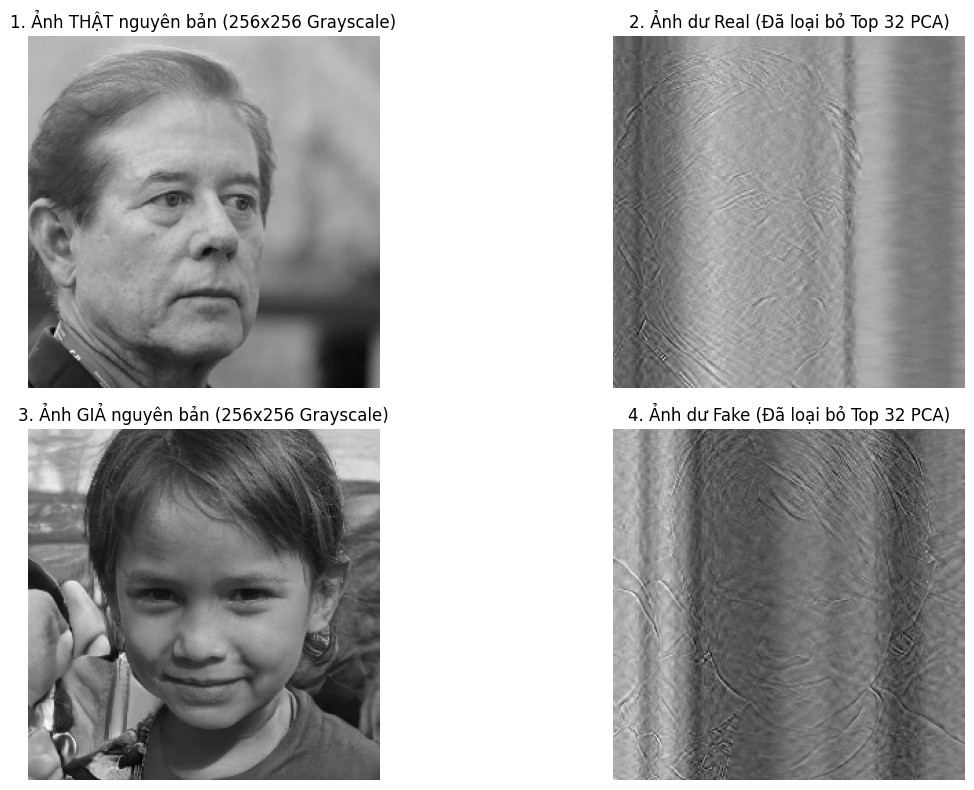


[THÀNH CÔNG] Tiền xử lý hoàn tất!
 -> Kích thước ma trận ảnh dư Real: (256, 256)
 -> Kích thước ma trận ảnh dư Fake: (256, 256)


In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def get_pca_residual_image(img_gray, num_components_to_remove=32):
    img_data = img_gray.astype(np.float64)

    pca = PCA()
    pca.fit(img_data)

    img_transformed = pca.transform(img_data)

    img_transformed_residual = img_transformed.copy()
    img_transformed_residual[:, :num_components_to_remove] = 0

    residual_data = pca.inverse_transform(img_transformed_residual)

    residual_img_8u = cv2.convertScaleAbs(residual_data)

    return residual_img_8u

print("--- Đang tiến hành tiền xử lý và trích xuất ảnh dư PCA ---")

real_files = [f for f in os.listdir('/content/project_data/real') if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
fake_files = [f for f in os.listdir('/content/project_data/fake') if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if len(real_files) > 0 and len(fake_files) > 0:
    real_sample_path = os.path.join('/content/project_data/real', real_files[0])
    fake_sample_path = os.path.join('/content/project_data/fake', fake_files[0])

    img_real_raw = cv2.imread(real_sample_path, cv2.IMREAD_GRAYSCALE)
    img_fake_raw = cv2.imread(fake_sample_path, cv2.IMREAD_GRAYSCALE)

    img_real_resized = cv2.resize(img_real_raw, (256, 256))
    img_fake_resized = cv2.resize(img_fake_raw, (256, 256))

    N_components = 32
    residual_real = get_pca_residual_image(img_real_resized, num_components_to_remove=N_components)
    residual_fake = get_pca_residual_image(img_fake_resized, num_components_to_remove=N_components)

    plt.figure(figsize=(14, 8))

    plt.subplot(2, 2, 1)
    plt.imshow(img_real_resized, cmap='gray')
    plt.title("1. Ảnh THẬT nguyên bản (256x256 Grayscale)")
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(residual_real, cmap='gray')
    plt.title(f"2. Ảnh dư Real (Đã loại bỏ Top {N_components} PCA)")
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.imshow(img_fake_resized, cmap='gray')
    plt.title("3. Ảnh GIẢ nguyên bản (256x256 Grayscale)")
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.imshow(residual_fake, cmap='gray')
    plt.title(f"4. Ảnh dư Fake (Đã loại bỏ Top {N_components} PCA)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    print(f"\n[THÀNH CÔNG] Tiền xử lý hoàn tất!")
    print(f" -> Kích thước ma trận ảnh dư Real: {residual_real.shape}")
    print(f" -> Kích thước ma trận ảnh dư Fake: {residual_fake.shape}")
else:
    print("[LỖI] Không tìm thấy ảnh trong thư mục /content/project_data/. Hãy chắc chắn bạn đã giải nén thành công dữ liệu ở Ô số 1.")


In [4]:
import os
import numpy as np
import cv2
from skimage.feature import local_binary_pattern
from tqdm import tqdm

N_components = 32
LBP_P, LBP_R = 8, 1
FFT_BINS    = 64
LBP_BINS    = LBP_P * (LBP_P - 1) + 3
NOISE_BINS  = 64
FEATURE_DIM = FFT_BINS + LBP_BINS + NOISE_BINS

def extract_fft(gray):
    f   = np.fft.fftshift(np.fft.fft2(gray.astype(np.float32)))
    mag = np.log1p(np.abs(f))
    hist, _ = np.histogram(mag, bins=FFT_BINS, range=(mag.min(), mag.max()))
    return hist.astype(np.float32) / (hist.sum() + 1e-8)

def extract_lbp(gray):
    lbp = local_binary_pattern(gray, P=LBP_P, R=LBP_R, method='nri_uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=LBP_BINS, range=(0, LBP_BINS))
    return hist.astype(np.float32) / (hist.sum() + 1e-8)

def extract_noise(gray):
    noise = gray.astype(np.float32) - cv2.GaussianBlur(gray, (5, 5), 0).astype(np.float32)
    hist, _ = np.histogram(noise, bins=NOISE_BINS, range=(-50, 50))
    return hist.astype(np.float32) / (hist.sum() + 1e-8)

def extract_features(gray):
    return np.concatenate([extract_fft(gray), extract_lbp(gray), extract_noise(gray)])

feature_groups = {
    'fft':   (0,                        FFT_BINS),
    'lbp':   (FFT_BINS,                 FFT_BINS + LBP_BINS),
    'noise': (FFT_BINS + LBP_BINS,      FEATURE_DIM),
}
feature_names = ([f'fft_{i}'   for i in range(FFT_BINS)] +
                 [f'lbp_{i}'   for i in range(LBP_BINS)] +
                 [f'noise_{i}' for i in range(NOISE_BINS)])

DATA_DIR = '/content/project_data'
X_all, y_all, paths_all = [], [], []
for label_name, label_idx in [('real', 0), ('fake', 1)]:
    folder = os.path.join(DATA_DIR, label_name)
    files  = sorted([f for f in os.listdir(folder)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f'[{label_name.upper()}] {len(files)} ảnh')
    for fname in tqdm(files, desc=label_name):
        img = cv2.imread(os.path.join(folder, fname), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (256, 256))
        residual = get_pca_residual_image(img, num_components_to_remove=N_components)
        X_all.append(extract_features(residual))
        y_all.append(label_idx)
        paths_all.append(os.path.join(folder, fname))

X_all = np.asarray(X_all, dtype=np.float32)
y_all = np.asarray(y_all, dtype=np.int32)
assert X_all.shape[1] == FEATURE_DIM, f'Sai chiều đặc trưng: {X_all.shape[1]} != {FEATURE_DIM}'
print(f'\nTổng: {len(y_all)} ảnh | real={(y_all==0).sum()} fake={(y_all==1).sum()} | dim={X_all.shape[1]}')


[REAL] 20000 ảnh


real: 100%|██████████| 20000/20000 [39:51<00:00,  8.36it/s]


[FAKE] 20000 ảnh


fake: 100%|██████████| 20000/20000 [34:19<00:00,  9.71it/s]



Tổng: 40000 ảnh | real=20000 fake=20000 | dim=187


In [5]:
import os, pickle
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

OUTPUT_DIR = '/content/features'
os.makedirs(OUTPUT_DIR, exist_ok=True)

idx = np.arange(len(y_all))
idx_train, idx_tmp = train_test_split(idx,      test_size=0.2, stratify=y_all,           random_state=42)
idx_val,   idx_test = train_test_split(idx_tmp, test_size=0.5, stratify=y_all[idx_tmp],  random_state=42)

scaler = StandardScaler().fit(X_all[idx_train])
config = {'img_size': 256, 'pca_remove': N_components, 'feature_dim': FEATURE_DIM,
          'lbp_method': 'nri_uniform', 'split': '80/10/10'}

for name, ids in [('train', idx_train), ('val', idx_val), ('test', idx_test)]:
    Xs = scaler.transform(X_all[ids]).astype(np.float32)
    ys = y_all[ids]
    ps = [paths_all[i] for i in ids]
    with open(f'{OUTPUT_DIR}/{name}.pkl', 'wb') as f:
        pickle.dump({'X': Xs, 'y': ys, 'paths': ps,
                     'feature_names': feature_names,
                     'feature_groups': feature_groups,
                     'config': config}, f)
    print(f'  {name}: {len(ys)} ảnh | real={(ys==0).sum()} fake={(ys==1).sum()} | shape={Xs.shape} -> {name}.pkl')

with open(f'{OUTPUT_DIR}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('\n✅ XONG phần đặc trưng (người B).')
print('   Bàn giao người C: train.pkl, val.pkl, test.pkl, scaler.pkl')
print('   feature_groups =', feature_groups, '-> người C dùng để ablation.')


  train: 32000 ảnh | real=16000 fake=16000 | shape=(32000, 187) -> train.pkl
  val: 4000 ảnh | real=2000 fake=2000 | shape=(4000, 187) -> val.pkl
  test: 4000 ảnh | real=2000 fake=2000 | shape=(4000, 187) -> test.pkl

✅ XONG phần đặc trưng (người B).
   Bàn giao người C: train.pkl, val.pkl, test.pkl, scaler.pkl
   feature_groups = {'fft': (0, 64), 'lbp': (64, 123), 'noise': (123, 187)} -> người C dùng để ablation.


In [6]:
import shutil, os

DST = '/content/drive/MyDrive/Deepfake_project/features'
os.makedirs(DST, exist_ok=True)

for fname in ['train.pkl', 'val.pkl', 'test.pkl', 'scaler.pkl']:
    shutil.copy(f'/content/features/{fname}', f'{DST}/{fname}')
    print('Đã lưu:', fname)

print('Xong! File đặc trưng đã an toàn trên Drive.')


Đã lưu: train.pkl
Đã lưu: val.pkl
Đã lưu: test.pkl
Đã lưu: scaler.pkl
Xong! File đặc trưng đã an toàn trên Drive.
